<a href="https://colab.research.google.com/github/cleybersilva/AppSGA/blob/master/C%C3%B3pia_de_2026S1_RAG_usandoLLM_sol.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

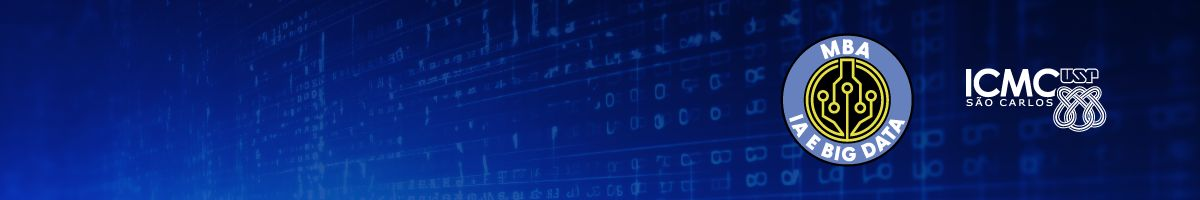

<br>
<font size="3"><center><b>Monitoria II – Retrieval-Augmented Generation</b></center></font>

<font size="3"><center>Prof. Dr. Renato Moraes Silva</center></font>
<br/>

# <center>Large Language Models (LLMs)</center>

Neste exercício, iremos aprender como usar Python para interagir com LLMs.

Primeiro, iremos instalar as principais bibliotecas.

In [ ]:
# caso você obtenha um erro de codificação, descomente a linha abaixo
import locale
locale.getpreferredencoding = lambda: "UTF-8"

!pip install transformers --quiet

!pip install accelerate --quiet
!pip install bitsandbytes --quiet

!pip install -U langchain langchain-huggingface langchain-community langchain-text-splitters --quiet

!pip install bs4 --quiet

!pip install pypdf --quiet

!pip install pymupdf4llm --quiet

!pip install sentence-transformers --quiet
!pip install chromadb --quiet

!pip install "unstructured[md]" --quiet

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 17.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 112.5/112.5 kB 11.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.5/2.5 MB 100.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 61.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 64.7/64.7 kB 6.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 51.0/51.0 kB 5.2 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires requests==2.32.4, but you have requests 2.32.5 which is incompatible.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 333.7/333.7 kB 21.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.3/84.3 kB 7.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.9/24.9 MB 65.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━

Iremos importar as principais bibliotecas.

In [ ]:
from langchain_huggingface.llms import HuggingFacePipeline

import transformers
from transformers import AutoTokenizer, AutoModelForCausalLM, pipeline
import torch



Iremos inicializar os modelos.

**Obs.** O código apresentado abaixo requer o uso de GPU. Geralmente, o uso de GPU é ativado automaticamente no Google Colab. Mas, caso você obtenha algum erro relacionado às bibliotecas accelerate ou bitsandbytes, ative a GPU manualmente e tente executar a célula novamente.

O início da célula abaixo contém alguns nomes de modelos comentados. Teste um ou mais deles, além de outros que você pode encontrar aqui: <https://huggingface.co/models?pipeline_tag=text-generation>. A qualidade das respostas pode variar bastante de acordo com o modelo escolhido.

In [ ]:
# modelName = "HuggingFaceH4/zephyr-7b-beta"
# modelName = "google/gemma-2b"
# modelName = "meta-llama/Meta-Llama-3-8B"
# model_name = "BAAI/bge-large-en-v1.5"
modelName = "microsoft/Phi-3-mini-4k-instruct"

tokenizer = AutoTokenizer.from_pretrained(modelName)

from transformers import BitsAndBytesConfig

quantization_config = BitsAndBytesConfig(load_in_4bit=True,
                                         load_in_8bit=False)


model = AutoModelForCausalLM.from_pretrained(
    modelName,
    device_map='auto',
    quantization_config=quantization_config)

# parametros:
# - max_new_tokens: limite superior para a quantidade de texto gerado
# - temperature: valores mais próximos de 1 aumentam a aleatoriedade e a criatividade do texto gerado
hf_pipe = transformers.pipeline("text-generation",
                   model=model,
                   tokenizer=tokenizer,
                   max_new_tokens=500,
                   temperature=0.7,
                   eos_token_id=tokenizer.eos_token_id
                  )

llm_pipeline = HuggingFacePipeline(pipeline=hf_pipe)

print("Modelo carregado com sucesso")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/967 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

tokenizer.model:   0%|          | 0.00/500k [00:00<?, ?B/s]

...

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/195 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/181 [00:00<?, ?B/s]

Passing `generation_config` together with generation-related arguments=({'max_new_tokens', 'temperature', 'eos_token_id'}) is deprecated and will be removed in future versions. Please pass either a `generation_config` object OR all generation parameters explicitly, but not both.


Modelo carregado com sucesso


Teste a geração de texto.

In [ ]:
def getResposta(pergunta):

    #######################zzz### COMPLETE O CÓDIGO AQUI  ########################

    prompt = f"""Responda apenas a pergunta abaixo de forma objetiva.

            Pergunta: {pergunta}
            Resposta:
    """

    resposta = hf_pipe(prompt)

    # Extrai o texto gerado
    texto = resposta[0]["generated_text"]

    # Remove o prompt da saída
    strResposta = texto.replace(prompt, "").strip()

    ##############################################################################

    return strResposta

pergunta = """Explique o que é a camada de atenção em uma rede Transformer.
"""

# testa a função
resposta = getResposta(pergunta)

print(resposta)

Both `max_new_tokens` (=500) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


# Retrieval-augmented generation (RAG)


Vamos fazer o download de um PDF: <https://brasileiraspln.com/livro-pln/3a-edicao/parte-aplicacoes/cap-fake-news/cap-fake-news.pdf>

In [ ]:
import os
import requests

def download(url, save_path):

    # Cria a pasta se não existir
    os.makedirs(os.path.dirname(save_path), exist_ok=True)

    print("Baixando...")
    response = requests.get(url)

    if response.status_code != 200:
        print("Erro ao baixar:", response.status_code)
        return

    # Salva o conteúdo diretamente em arquivo
    with open(save_path, "wb") as f:
        f.write(response.content)

    print(f"Download concluído. Arquivo salvo em: {save_path}")

url = 'https://brasileiraspln.com/livro-pln/3a-edicao/parte-aplicacoes/cap-fake-news/cap-fake-news.pdf'
pathFile = 'dados/cap-fake-news.pdf'
download(url, pathFile)

Lendo o arquivo.

In [ ]:
from langchain_community.document_loaders import PyPDFLoader

########################## COMPLETE O CÓDIGO AQUI  ########################

loader = PyPDFLoader(pathFile)
docs = loader.load()

for i, pagina in enumerate(docs[1:3]):
    print(f"\n--- Página {i+1} ---\n")
    print(pagina.page_content)

###########################################################################

Usando um leitor melhor.

In [ ]:
import pymupdf4llm  # precisa instalar: pip install pymupdf4llm

md_path = os.path.splitext(pathFile)[0] + ".md"

########################## COMPLETE O CÓDIGO AQUI  ########################

md_text = pymupdf4llm.to_markdown(pathFile)

###########################################################################

with open(md_path, "w", encoding="utf-8") as f:
    f.write(md_text)
    print(f"Convertido: {pathFile} para {md_path}")


Vamos carregar um arquivo markdown.

In [ ]:
from langchain_community.document_loaders import UnstructuredMarkdownLoader

########################## COMPLETE O CÓDIGO AQUI  ########################

loader = UnstructuredMarkdownLoader(md_path)
docs = loader.load()

for d in docs[0:2]:
    print(d.page_content)

###########################################################################


Vamos carregar uma página da Internet.

In [ ]:
#!pip install langchain langchain-text-splitters langchain-community bs4 --quiet

from langchain_community.document_loaders import WebBaseLoader


url = "https://mba.iabigdata.icmc.usp.br/inscricoes-abertas-para-a-6a-turma-do-mba-em-inteligencia-artificial-e-big-data-da-usp-sao-carlos/"

############################# COMPLETE O CÓDIGO AQUI  ########################

loader = WebBaseLoader(url)
data = loader.load()

##############################################################################

display(data)

Iremos dividir o texto em pequenos pedaços, chamados de *chunks*.

In [ ]:
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_community.vectorstores import Chroma

############################# COMPLETE O CÓDIGO AQUI  ########################

text_splitter = RecursiveCharacterTextSplitter(chunk_size=500, chunk_overlap=200)
splits = text_splitter.split_documents(data)

for text in splits:
  print("\n"+10*"=")
  print(splits)

##############################################################################


Iremos criar embeddings para cada pedaço de texto. Primeiro, iremos carregar o modelo de embeddings.

In [ ]:
#!pip install sentence-transformers --quiet

from langchain_community.embeddings import HuggingFaceEmbeddings

embeddings_modelName = 'rufimelo/bert-large-portuguese-cased-sts'

############################# COMPLETE O CÓDIGO AQUI  ########################

embeddingModel = HuggingFaceEmbeddings(model_name=embeddings_modelName)

##############################################################################

print("Modelo carregado com sucesso!")



Agora iremos gerar as embeddings.

In [ ]:
#!pip install chromadb --quiet
from langchain_community.vectorstores import Chroma

############################# COMPLETE O CÓDIGO AQUI  ########################

vectorstore = Chroma.from_documents(documents=splits, embedding=embeddingModel)
retriever = vectorstore.as_retriever(kwargs={"k": 7}) # quantidade de documentos que devem ser retornados

##############################################################################

Iremos testar as embeddings.

In [ ]:
pergunta = "Qual é a taxa de inscrição?"

############################# COMPLETE O CÓDIGO AQUI  ########################

docs = retriever.invoke(pergunta)  # similarity_search_by_vector(pergunta)

for doc in docs:
  print('\n\n', doc)

##############################################################################


Iremos usar os documentos mais próximos como contexto para a LLM. Para estruturar a pergunta, deve-se usar um template, como no exemplo abaixo:

```
### System:
Escreva aqui as instruções iniciais.
        
### Context:
{context}
        
### User:
{question}
        
### Response:
"""
```

In [ ]:
from langchain_core.prompts import ChatPromptTemplate
from langchain_core.runnables import RunnablePassthrough

# prompt atualizado
template = """
Você é um assistente respeitoso e honesto. Responda usando apenas o contexto.
Se não souber, diga que não sabe.

Contexto:
{context}

Pergunta:
{question}

Resposta:
"""

############################# COMPLETE O CÓDIGO AQUI  ########################

prompt = ChatPromptTemplate.from_template(template)

def format_docs(docs):
    return "\n\n".join([d.page_content for d in docs])

##############################################################################

# pipeline RAG
rag_chain = (
    {
        "context": retriever | format_docs,
        "question": RunnablePassthrough(),
    }
    | prompt
    | llm_pipeline
)

print("Chain criada com sucesso!")


Iremos criar uma função para fazer a pergunta ao modelo.

In [ ]:
def perguntaArquivo(strPrompt):

    resposta = rag_chain.invoke(strPrompt)
    return resposta


# Teste
pergunta = "Qual é a taxa de inscrição?"
resposta = perguntaArquivo(pergunta)

print("\n=== RESPOSTA ===")
print(resposta)
